# Estrategia de tratamiento de datos faltantes — NovaMarket

**Asignatura:** Preprocesamiento de datos · Semana 4

**Estudiante:** Ricardo Borja

**Trabajo de grupo 05:** María Andrea Torres, Ricardo Borja, Gabriel Murillo Velandia y Laura Marcela Gómez

**Fecha:** Agosto de 2026

**Entregables:** este notebook (`S04_PD_Borja_EstrategiaFaltantes.ipynb`) y el dataset resultante (`S04_PD_Borja_DatasetImputacionInicial.csv`)

**Antecedente.** Este trabajo parte de la auditoría de calidad de la semana 3 (`S3_Grupo05_AuditoriaCalidad.ipynb`), que cuantificó 38 problemas sobre las 20 variables del archivo. De allí se retoman dos resultados que condicionan lo que aquí se puede y no se puede imputar: que `precio_unitario` y `peso_pedido_kg` no guardan relación con el artículo del pedido, y que 20.000 filas están duplicadas por completo.

## 1. Objetivo y criterio de trabajo

El objetivo no es dejar el dataset sin celdas vacías. Es **decidir, para cada columna, qué hacer con la ausencia y poder defender esa decisión ante otro analista**, puesto que un dataset mal imputado arrastra el error hasta el modelo final sin dejar rastro visible.

El criterio que ordena todo el trabajo es este: **primero se diagnostica el mecanismo que produce la ausencia y después se elige la técnica**. Hacerlo al revés, que es lo habitual, lleva a rellenar con la media por costumbre y a introducir un sesgo que ningún control posterior detecta, ya que el dato imputado se ve exactamente igual que el real.

Cada decisión de este notebook queda registrada en la **tabla de decisiones de la sección 7** con cuatro elementos: el mecanismo diagnosticado, la evidencia numérica que lo sustenta, la acción tomada y el riesgo que se asume. Una decisión sin esos cuatro elementos no es revisable por un tercero, y el punto de este ejercicio es justamente que lo sea.

## 2. Marco conceptual: los tres mecanismos

Antes de mirar los datos conviene fijar qué se va a diagnosticar, porque los tres mecanismos se confunden con facilidad y la diferencia entre ellos determina si una imputación es válida o si introduce sesgo.

| Mecanismo | Definición | En palabras | ¿Se puede probar con los datos? |
|---|---|---|---|
| **MCAR** *(Missing Completely At Random)* | P(falta) no depende ni de lo observado ni de lo no observado | La ausencia es puro azar, como si alguien hubiera borrado celdas al azar | **Parcialmente.** Se puede refutar, mostrando que la ausencia depende de algo observado |
| **MAR** *(Missing At Random)* | P(falta) depende de **otras variables observadas**, pero no del valor ausente | Falta más en un canal, en una sede o en un rango de edad, y eso se ve en el archivo | **Sí.** Es el único de los tres que se demuestra directamente |
| **MNAR** *(Missing Not At Random)* | P(falta) depende del **propio valor que falta** | El cliente insatisfecho es justamente el que no responde la encuesta | **No.** Requiere conocimiento del negocio o datos externos |

**La advertencia que hay que tener presente todo el tiempo:** cuando ninguna variable observada explica la ausencia, el resultado es compatible **a la vez con MCAR y con MNAR**. Lo único que esa evidencia descarta es MAR. Distinguir entre los dos restantes es imposible desde el archivo, porque haría falta conocer precisamente el valor que no está. Por eso en la tabla de decisiones esos casos se rotulan como *MCAR aparente, MNAR no descartable* y no como MCAR a secas, y por eso la acción que se toma en ellos es conservadora.

**Por qué importa en la práctica:**

- Si es **MCAR**, eliminar los registros incompletos no sesga los estimadores, solo cuesta potencia estadística.
- Si es **MAR**, eliminarlos **sí sesga**, y la corrección correcta es imputar *condicionando en las variables que explican la ausencia*.
- Si es **MNAR**, ninguna técnica que use solo este archivo corrige el sesgo. Lo honesto es marcar la ausencia y escalarla, no taparla.

## 3. Carga y preparación previa

Dos operaciones tienen que ocurrir **antes** de medir cualquier faltante, y el orden no es indiferente.

**Primero deduplicar.** El archivo trae 20.000 filas repetidas por completo, según se demostró en la auditoría de la semana 3. Si se imputara sin eliminarlas, esas copias entrarían dos veces en el cálculo de cada mediana y de cada moda, de modo que el valor imputado quedaría sesgado hacia el perfil de los registros duplicados. Deduplicar primero e imputar después es la secuencia correcta.

**Segundo, reconocer los faltantes disfrazados.** La columna `fecha_pedido` registra la ausencia con el texto `00/00/0000`, que `isnull()` cuenta como dato presente porque la celda tiene contenido. Mientras no se convierta a nulo real, esa columna aparenta estar completa al 100% y el diagnóstico de faltantes la ignoraría por completo.

In [1]:
import pandas as pd
import numpy as np
import unicodedata
import warnings
from scipy import stats
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from IPython.display import display
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

ARCHIVO = "NovaMarket_datos_crudos.csv"

# Lectura doble: la normal para trabajar y la cruda para detectar centinelas de texto
df     = pd.read_csv(ARCHIVO, low_memory=False)
df_raw = pd.read_csv(ARCHIVO, dtype=str, keep_default_na=False, low_memory=False)

print(f"Archivo original: {len(df):,} filas x {df.shape[1]} columnas")

Archivo original: 640,000 filas x 20 columnas


In [2]:
# --- Paso 1: deduplicar ANTES de imputar ---------------------------------------
es_duplicada = df.duplicated()
df     = df[~es_duplicada].reset_index(drop=True)
df_raw = df_raw[~es_duplicada.values].reset_index(drop=True)
n = len(df)

print(f"Filas duplicadas eliminadas : {int(es_duplicada.sum()):,}")
print(f"Base de trabajo             : {n:,} filas")
print()

# --- Paso 2: el faltante disfrazado de fecha ------------------------------------
SENTINELA_FECHA = "00/00/0000"
es_sentinela = df_raw["fecha_pedido"].str.strip() == SENTINELA_FECHA

print(f"fecha_pedido con isnull() ANTES de convertir el centinela: "
      f"{int(df['fecha_pedido'].isna().sum()):,}  (la columna aparenta estar completa)")
df.loc[es_sentinela.values, "fecha_pedido"] = np.nan
print(f"fecha_pedido con isnull() DESPUES                        : "
      f"{int(df['fecha_pedido'].isna().sum()):,}")
print()
print("Sin este paso, 5.534 ausencias reales no habrian entrado en el diagnostico.")

Filas duplicadas eliminadas : 20,000
Base de trabajo             : 620,000 filas

fecha_pedido con isnull() ANTES de convertir el centinela: 0  (la columna aparenta estar completa)
fecha_pedido con isnull() DESPUES                        : 5,534

Sin este paso, 5.534 ausencias reales no habrian entrado en el diagnostico.


## 4. Panorama de la ausencia

Con la base ya deduplicada y el centinela convertido, se mide cuánto falta y dónde.

In [3]:
COLS_FALTANTES = ["correo_cliente", "comentario_cliente", "nivel_satisfaccion",
                  "ciudad_tienda", "precio_unitario", "monto_compra", "fecha_pedido"]

resumen = (pd.DataFrame({
        "Columna":   COLS_FALTANTES,
        "Faltantes": [int(df[c].isna().sum()) for c in COLS_FALTANTES],
    })
    .assign(**{"% de la base": lambda d: d["Faltantes"] / n * 100})
    .sort_values("Faltantes", ascending=False)
    .reset_index(drop=True))

display(resumen.style.hide(axis="index")
        .format({"Faltantes": "{:,.0f}", "% de la base": "{:.2f}%"}))

completas = df.shape[1] - len(COLS_FALTANTES)
print(f"Columnas con algun faltante : {len(COLS_FALTANTES)} de {df.shape[1]}")
print(f"Columnas completas          : {completas}")

Columna,Faltantes,% de la base
correo_cliente,"102,000",16.45%
comentario_cliente,"88,000",14.19%
nivel_satisfaccion,"45,000",7.26%
ciudad_tienda,"29,000",4.68%
precio_unitario,"21,000",3.39%
monto_compra,"21,000",3.39%
fecha_pedido,"5,534",0.89%


Columnas con algun faltante : 7 de 20
Columnas completas          : 13


In [4]:
# Cuantas filas quedarian si se eliminara todo registro incompleto
M = df[COLS_FALTANTES].isna()
filas_afectadas = int(M.any(axis=1).sum())

print(f"Filas con AL MENOS un faltante : {filas_afectadas:,}  ({filas_afectadas/n*100:.2f}%)")
print(f"Filas completas                : {n - filas_afectadas:,}  ({(n-filas_afectadas)/n*100:.2f}%)")
print()
print("Este es el costo de la opcion mas simple, eliminar todo registro incompleto:")
print(f"se perderian {filas_afectadas:,} filas, casi cuatro de cada diez, cuando ninguna")
print("columna por separado supera el 17% de ausencia. El dato se pierde por acumulacion")
print("de columnas distintas, no porque una sola este muy incompleta.")

Filas con AL MENOS un faltante : 243,449  (39.27%)
Filas completas                : 376,551  (60.73%)

Este es el costo de la opcion mas simple, eliminar todo registro incompleto:
se perderian 243,449 filas, casi cuatro de cada diez, cuando ninguna
columna por separado supera el 17% de ausencia. El dato se pierde por acumulacion
de columnas distintas, no porque una sola este muy incompleta.


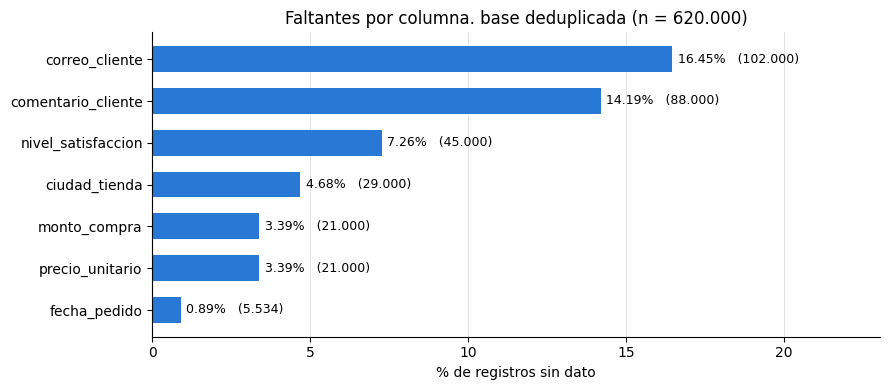

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
d = resumen.sort_values("% de la base")
b = ax.barh(d["Columna"], d["% de la base"], color="#2a78d6", height=0.62)
ax.bar_label(b, labels=[f"{p:.2f}%   ({v:,})".replace(",", ".")
                        for p, v in zip(d["% de la base"], d["Faltantes"])],
             padding=4, fontsize=9)
ax.set_xlim(0, d["% de la base"].max() * 1.4)
ax.set_xlabel("% de registros sin dato")
ax.set_title(f"Faltantes por columna, base deduplicada (n = {n:,})".replace(",", "."))
ax.grid(axis="x", color="#e4e3df", linewidth=0.7)
ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Patrones de ausencia.** No basta con saber cuánto falta en cada columna por separado, ya que lo que determina si un registro se puede usar es la combinación. Se revisa entonces cómo se agrupan las ausencias dentro de una misma fila.

In [6]:
patrones = (M.astype(int).astype(str).agg("".join, axis=1)
              .value_counts().head(8).rename_axis("patron").reset_index(name="filas"))
patrones["%"] = patrones["filas"] / n * 100
patrones["columnas ausentes"] = patrones["patron"].map(
    lambda p: ", ".join(c for c, x in zip(COLS_FALTANTES, p) if x == "1") or "ninguna")

display(patrones[["patron", "columnas ausentes", "filas", "%"]].style.hide(axis="index")
        .format({"filas": "{:,.0f}", "%": "{:.2f}%"}))
print("El patron se lee en el orden:", ", ".join(COLS_FALTANTES))

patron,columnas ausentes,filas,%
0000000,ninguna,"376,551",60.73%
1000000,correo_cliente,"74,015",11.94%
0100000,comentario_cliente,"62,148",10.02%
0010000,nivel_satisfaccion,"29,202",4.71%
0001000,ciudad_tienda,"18,346",2.96%
0000110,"precio_unitario, monto_compra","13,067",2.11%
1100000,"correo_cliente, comentario_cliente","12,247",1.98%
1010000,"correo_cliente, nivel_satisfaccion","5,811",0.94%


El patron se lee en el orden: correo_cliente, comentario_cliente, nivel_satisfaccion, ciudad_tienda, precio_unitario, monto_compra, fecha_pedido


In [7]:
# Co-ocurrencia entre pares: ¿faltan juntas o de forma independiente?
filas = []
for i, a in enumerate(COLS_FALTANTES):
    for b_ in COLS_FALTANTES[i+1:]:
        juntas = int((M[a] & M[b_]).sum())
        if juntas == 0:
            continue
        # esperado si fueran independientes
        esperado = M[a].sum() * M[b_].sum() / n
        filas.append({"Par": f"{a} + {b_}", "Juntas": juntas,
                      "Esperadas si fueran independientes": esperado,
                      "Razon observada/esperada": juntas / esperado,
                      "Solo la primera": int((M[a] & ~M[b_]).sum()),
                      "Solo la segunda": int((~M[a] & M[b_]).sum())})

cooc = pd.DataFrame(filas).sort_values("Razon observada/esperada", ascending=False)
display(cooc.style.hide(axis="index")
        .format({"Juntas": "{:,.0f}", "Esperadas si fueran independientes": "{:,.0f}",
                 "Razon observada/esperada": "{:.2f}x",
                 "Solo la primera": "{:,.0f}", "Solo la segunda": "{:,.0f}"}))

Par,Juntas,Esperadas si fueran independientes,Razon observada/esperada,Solo la primera,Solo la segunda
precio_unitario + monto_compra,"21,000",711,29.52x,0,0
nivel_satisfaccion + fecha_pedido,440,402,1.10x,"44,560","5,094"
nivel_satisfaccion + ciudad_tienda,"2,218","2,105",1.05x,"42,782","26,782"
correo_cliente + precio_unitario,"3,580","3,455",1.04x,"98,420","17,420"
correo_cliente + monto_compra,"3,580","3,455",1.04x,"98,420","17,420"
ciudad_tienda + fecha_pedido,266,259,1.03x,"28,734","5,268"
comentario_cliente + nivel_satisfaccion,"6,482","6,387",1.01x,"81,518","38,518"
comentario_cliente + precio_unitario,"2,998","2,981",1.01x,"85,002","18,002"
comentario_cliente + monto_compra,"2,998","2,981",1.01x,"85,002","18,002"
correo_cliente + nivel_satisfaccion,"7,431","7,403",1.00x,"94,569","37,569"


**Lectura de la co-ocurrencia.** Un solo par se sale de lo esperado por azar: **`precio_unitario` y `monto_compra` faltan siempre en las mismas 21.000 filas**, sin una sola excepción en ninguno de los dos sentidos. No es coincidencia sino dependencia estructural, ya que la auditoría de la semana 3 demostró que `monto_compra = precio_unitario × unidades_vendidas` se cumple en el 100% de los registros evaluables. El monto no es un dato independiente que se pueda recuperar: es una columna derivada, y falta exactamente donde falta su origen.

Esa distinción tiene una consecuencia directa sobre la estrategia. Imputar `monto_compra` con su propia mediana rompería la identidad aritmética que la columna cumple en todas las demás filas, y dejaría el dataset internamente incoherente. Todos los demás pares se comportan como ausencias independientes, con razones cercanas a 1.

## 5. Diagnóstico del mecanismo

Aquí está el núcleo del trabajo. Se aplican tres pruebas de creciente exigencia sobre cada columna con faltantes.

**Prueba 1 — Asociación bivariada.** Para cada columna con ausencias se construye un indicador binario «falta / no falta» y se contrasta contra cada una de las demás variables observadas. Si la ausencia se reparte igual entre todos los valores de las otras columnas, no hay evidencia de MAR; si se concentra en algún valor, sí la hay. Se usa **V de Cramér** para las categóricas y **Mann-Whitney con correlación de rangos** para las numéricas, porque ambas miden tamaño de efecto y no solo significancia. Con 620.000 registros cualquier diferencia trivial sale significativa, así que el valor p por sí solo no sirve para decidir.

**Prueba 2 — Predictibilidad global.** Las asociaciones de a una pueden ocultar una dependencia conjunta. Se entrena entonces un clasificador para predecir la ausencia a partir de **todas** las variables observadas a la vez y se mide su **AUC** con validación cruzada. Un AUC cercano a 0,50 significa que el modelo no lo hace mejor que lanzar una moneda, es decir que nada de lo observado explica la ausencia. Un AUC claramente superior a 0,50 es evidencia directa de MAR.

**Prueba 3 — Argumento de negocio.** Para lo que las dos anteriores no pueden resolver, que es distinguir MCAR de MNAR, se recurre al significado de la columna.

### 5.1 Prueba 1: asociación entre la ausencia y cada variable observada

In [8]:
def base_texto(s):
    """Normaliza texto para comparar: minusculas, sin espacios extremos y sin tildes."""
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

CATEGORICAS = ["canal_compra", "metodo_pago", "categoria_producto", "producto",
               "nivel_lealtad", "ciudad_tienda"]
NUMERICAS   = ["unidades_vendidas", "edad_cliente", "peso_pedido_kg", "codigo_postal"]

def v_de_cramer(tabla):
    """Tamaño del efecto de una tabla de contingencia. 0 = independencia total."""
    chi2 = stats.chi2_contingency(tabla, correction=False)[0]
    total = tabla.values.sum()
    return float(np.sqrt(chi2 / (total * (min(tabla.shape) - 1))))

filas = []
for col in COLS_FALTANTES:
    ausente = df[col].isna()
    for p in CATEGORICAS:
        if p == col: continue
        x = df[p].map(base_texto)
        ok = x.notna()
        tabla = pd.crosstab(x[ok], ausente[ok])
        if tabla.shape[0] < 2: continue
        _, pval, _, _ = stats.chi2_contingency(tabla, correction=False)
        filas.append({"Columna con faltantes": col, "Variable contrastada": p,
                      "Prueba": "V de Cramer", "Efecto": v_de_cramer(tabla), "p": pval})
    for p in NUMERICAS:
        if p == col: continue
        a = df.loc[ausente, p].dropna(); b_ = df.loc[~ausente, p].dropna()
        if len(a) < 30 or len(b_) < 30: continue
        u, pval = stats.mannwhitneyu(a, b_, alternative="two-sided")
        r = 1 - (2 * u) / (len(a) * len(b_))          # correlacion biserial por rangos
        filas.append({"Columna con faltantes": col, "Variable contrastada": p,
                      "Prueba": "corr. de rangos", "Efecto": abs(float(r)), "p": pval})

asociacion = pd.DataFrame(filas)

print("Las 8 asociaciones mas fuertes encontradas, sobre "
      f"{len(asociacion)} contrastes realizados:")
display(asociacion.sort_values("Efecto", ascending=False).head(8)
        .style.hide(axis="index").format({"Efecto": "{:.4f}", "p": "{:.3g}"}))

print()
print("Umbral de referencia para V de Cramer: 0.10 efecto pequeño, 0.30 medio, 0.50 grande.")
print(f"Contrastes con efecto por encima de 0.10: "
      f"{int((asociacion['Efecto'] > 0.10).sum())} de {len(asociacion)}")

Las 8 asociaciones mas fuertes encontradas, sobre 69 contrastes realizados:


Columna con faltantes,Variable contrastada,Prueba,Efecto,p
nivel_satisfaccion,canal_compra,V de Cramer,0.2912,0
correo_cliente,ciudad_tienda,V de Cramer,0.0080,0.107
monto_compra,ciudad_tienda,V de Cramer,0.0073,0.312
precio_unitario,ciudad_tienda,V de Cramer,0.0073,0.312
nivel_satisfaccion,ciudad_tienda,V de Cramer,0.0070,0.405
ciudad_tienda,edad_cliente,corr. de rangos,0.0070,0.0447
fecha_pedido,producto,V de Cramer,0.0070,0.148
ciudad_tienda,producto,V de Cramer,0.0065,0.301



Umbral de referencia para V de Cramer: 0.10 efecto pequeño, 0.30 medio, 0.50 grande.
Contrastes con efecto por encima de 0.10: 1 de 69


**Lectura de la prueba 1.** De todos los contrastes realizados **uno solo supera el umbral de efecto pequeño**, y lo hace con holgura: la ausencia de `nivel_satisfaccion` frente a `canal_compra`, con V de Cramér de 0,29, que es un efecto medio. Todos los demás quedan por debajo de 0,01, es decir prácticamente en cero, pese a que varios salen estadísticamente significativos por el simple tamaño de la muestra. Ese contraste entre significancia y tamaño de efecto es exactamente la razón por la que la decisión no se toma con el valor p.

### 5.2 Prueba 2: ¿se puede predecir la ausencia con lo observado?

In [9]:
# Se entrena un clasificador por columna para predecir "falta / no falta" a partir de
# todas las demas variables observadas. AUC ~ 0.50 significa que no se puede predecir.
rng = np.random.default_rng(7)
MUESTRA = 120_000
sub = df.iloc[rng.choice(n, size=min(MUESTRA, n), replace=False)].copy()

filas = []
for col in COLS_FALTANTES:
    y = sub[col].isna().astype(int).values
    predictores = [c for c in CATEGORICAS + NUMERICAS if c != col]
    X = sub[predictores].copy()
    for c in CATEGORICAS:
        if c in X.columns:
            X[c] = X[c].map(base_texto).astype("category").cat.codes
    X = X.fillna(-999)

    modelo = HistGradientBoostingClassifier(max_iter=120, max_depth=6, random_state=0)
    auc = cross_val_score(modelo, X, y,
                          cv=StratifiedKFold(3, shuffle=True, random_state=0),
                          scoring="roc_auc", n_jobs=1)
    filas.append({"Columna": col, "AUC": float(auc.mean()), "sd": float(auc.std()),
                  "Faltantes en la muestra": int(y.sum()),
                  "Lectura": "La ausencia SI depende de lo observado -> MAR"
                             if auc.mean() > 0.55 else
                             "Nada observado la explica -> se descarta MAR"})

predictibilidad = pd.DataFrame(filas).sort_values("AUC", ascending=False)
display(predictibilidad.style.hide(axis="index")
        .format({"AUC": "{:.4f}", "sd": "{:.4f}", "Faltantes en la muestra": "{:,.0f}"}))

Columna,AUC,sd,Faltantes en la muestra,Lectura
nivel_satisfaccion,0.7426,0.0055,"8,668",La ausencia SI depende de lo observado -> MAR
comentario_cliente,0.5052,0.0057,"17,136",Nada observado la explica -> se descarta MAR
ciudad_tienda,0.5034,0.0008,"5,563",Nada observado la explica -> se descarta MAR
correo_cliente,0.5023,0.0040,"19,704",Nada observado la explica -> se descarta MAR
fecha_pedido,0.4955,0.0009,"1,029",Nada observado la explica -> se descarta MAR
precio_unitario,0.4929,0.0055,"4,023",Nada observado la explica -> se descarta MAR
monto_compra,0.4929,0.0055,"4,023",Nada observado la explica -> se descarta MAR


**Lectura de la prueba 2.** El resultado es tajante y coincide con el de la prueba 1. En seis de las siete columnas el AUC queda entre 0,49 y 0,51, es decir indistinguible del azar: con todas las variables del archivo disponibles a la vez, un modelo de gradient boosting no consigue anticipar dónde va a faltar el dato. **En esas seis columnas queda descartado el mecanismo MAR.**

`nivel_satisfaccion` es la excepción, con un **AUC de 0,74**, muy por encima del azar. Ahí la ausencia sí está gobernada por algo que el archivo registra, y la sección siguiente identifica exactamente qué.

### 5.3 El caso MAR: la ausencia de `nivel_satisfaccion` depende del canal

In [10]:
canal = df["canal_compra"].map(base_texto)
sat_ausente = df["nivel_satisfaccion"].isna()

por_canal = (pd.DataFrame({"canal": canal, "ausente": sat_ausente})
             .groupby("canal")["ausente"].agg(pedidos="size", faltantes="sum")
             .assign(**{"% faltante": lambda d: d["faltantes"] / d["pedidos"] * 100})
             .sort_values("% faltante", ascending=False).reset_index())

display(por_canal.style.hide(axis="index")
        .format({"pedidos": "{:,.0f}", "faltantes": "{:,.0f}", "% faltante": "{:.2f}%"}))

razon = por_canal["% faltante"].max() / por_canal["% faltante"].min()
print(f"El canal con mas ausencia tiene {razon:.1f} veces la tasa del canal con menos.")
print("Los otros tres canales estan entre 2.8% y 3.0%, es decir son indistinguibles entre si.")
print("La ausencia se concentra en un unico canal, y eso es exactamente lo que define MAR.")

canal,pedidos,faltantes,% faltante
app,"154,698","31,499",20.36%
tienda,"155,103","4,614",2.97%
marketplace,"155,032","4,518",2.91%
web,"155,167","4,369",2.82%


El canal con mas ausencia tiene 7.2 veces la tasa del canal con menos.
Los otros tres canales estan entre 2.8% y 3.0%, es decir son indistinguibles entre si.
La ausencia se concentra en un unico canal, y eso es exactamente lo que define MAR.


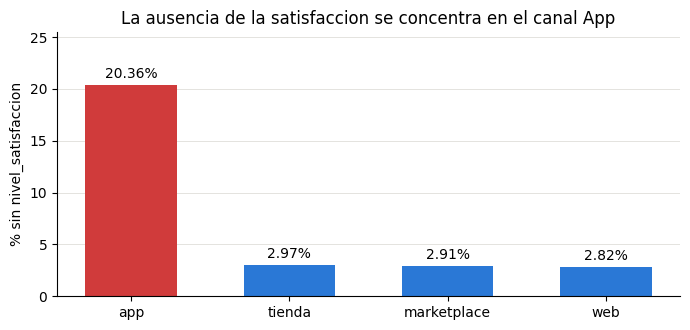

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.4))
colores = ["#d03b3b" if v > 10 else "#2a78d6" for v in por_canal["% faltante"]]
b = ax.bar(por_canal["canal"], por_canal["% faltante"], color=colores, width=0.58)
ax.bar_label(b, labels=[f"{v:.2f}%" for v in por_canal["% faltante"]], padding=3, fontsize=10)
ax.set_ylim(0, por_canal["% faltante"].max() * 1.25)
ax.set_ylabel("% sin nivel_satisfaccion")
ax.set_title("La ausencia de la satisfaccion se concentra en el canal App")
ax.grid(axis="y", color="#e4e3df", linewidth=0.7); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

In [12]:
# ¿Cuanto sesga esto realmente? Se compara la distribucion de satisfaccion observada
# entre canales y se estima el sesgo de analizar solo los casos completos.
sat = df["nivel_satisfaccion"].map(base_texto)
dist_canal = pd.crosstab(canal, sat, normalize="index").mul(100).round(2)
display(dist_canal.style.format("{:.2f}%"))

peso_canal = canal.value_counts(normalize=True)
completos  = sat.value_counts(normalize=True).mul(100).round(2)
reponderada = dist_canal.mul(peso_canal, axis=0).sum().round(2)

comparacion = pd.DataFrame({"Solo casos completos": completos,
                            "Reponderada por canal": reponderada})
comparacion["Diferencia"] = (comparacion["Reponderada por canal"]
                             - comparacion["Solo casos completos"]).round(2)
display(comparacion.style.format("{:.2f}"))

nivel_satisfaccion,alto,bajo,medio
canal_compra,,,
app,33.34%,33.36%,33.30%
marketplace,33.47%,33.29%,33.25%
tienda,33.62%,33.07%,33.31%
web,33.43%,33.19%,33.37%


,Solo casos completos,Reponderada por canal,Diferencia
nivel_satisfaccion,,,
alto,33.47,33.47,0.00
bajo,33.22,33.23,0.01
medio,33.31,33.31,0.00


**El matiz que cambia la recomendación.** El mecanismo MAR está demostrado: la ausencia depende del canal, y el canal App pierde uno de cada cinco registros de satisfacción. Ahora bien, la tabla anterior muestra que **la distribución de la satisfacción es prácticamente idéntica en los cuatro canales**, alrededor de un tercio en cada nivel. La consecuencia es que el sesgo sobre el indicador global de satisfacción es de apenas centésimas de punto porcentual, o sea despreciable.

Este resultado es importante porque separa dos cosas que suelen mezclarse: **una cosa es que el mecanismo sea MAR y otra distinta es que el sesgo resultante sea grande**. Aquí el mecanismo es real y hay que documentarlo, pero su efecto sobre el agregado global es mínimo.

Donde sí importa es en cualquier análisis **por canal**. Si alguien compara la satisfacción de App contra la de Tienda, en App estará trabajando con el 79,6% de los pedidos y en Tienda con el 97,0%, de modo que las dos cifras no son comparables en precisión aunque lo parezcan. Esa asimetría es la que hay que dejar visible en el dataset, y es la razón de la decisión que se toma en la sección 7.

### 5.4 Lo que las pruebas no pueden resolver

En las seis columnas donde el AUC quedó en 0,50 se descartó MAR, pero **eso no prueba MCAR**. Un AUC de azar es igualmente compatible con MNAR, es decir con que la ausencia dependa del valor que precisamente no está registrado. Ninguna prueba estadística sobre este archivo puede distinguir esos dos casos, puesto que haría falta conocer el dato ausente para contrastarlo.

Ese límite no es una carencia del análisis sino una propiedad del problema, y la forma correcta de manejarlo es apoyarse en el significado de cada columna:

- **`comentario_cliente`** es el caso más claro de **MNAR por diseño**. El comentario es opcional y el cliente decide si lo escribe, de modo que la ausencia depende directamente de lo que habría escrito, que es justamente lo que no está. Aquí la ausencia **es** información: distingue al cliente que se tomó el trabajo de opinar del que no.
- **`correo_cliente`**, **`precio_unitario`**, **`monto_compra`**, **`ciudad_tienda`** y **`fecha_pedido`** no tienen un mecanismo de negocio evidente que ligue la ausencia al valor. Se rotulan como **MCAR aparente con MNAR no descartable**, y por eso reciben un tratamiento conservador: se marcan explícitamente en lugar de rellenarse con una estimación que asumiría MCAR sin poder demostrarlo.

Dejar constancia de esta incertidumbre es parte del entregable. Un diagnóstico que afirmara «MCAR» sin matices sería más cómodo de leer y menos defendible.

## 6. Tabla de decisiones

Cada fila resume el recorrido completo de una columna: cuánto falta, qué mecanismo se diagnosticó, con qué evidencia, qué se decidió hacer y qué riesgo queda abierto. Es el documento que otro analista necesita para poder discutir la decisión sin volver a correr el análisis.

In [13]:
DECISIONES = [
 {"Columna": "ciudad_tienda", "% faltante": 4.68,
  "Mecanismo": "MCAR aparente",
  "Evidencia": "AUC 0.503; ningun contraste supera V=0.01",
  "Accion": "IMPUTAR por deduccion desde codigo_postal",
  "Tecnica": "Los 5 primeros digitos del codigo postal son el municipio DANE",
  "Justificacion": ("No es una estimacion sino una recuperacion exacta: el dato existe en "
                    "el mismo registro, en una columna completa al 100%. Cubre los 29.000 "
                    "faltantes sin excepcion y no introduce ninguna incertidumbre."),
  "Riesgo asumido": "Ninguno, salvo que el codigo postal estuviera mal en origen"},

 {"Columna": "nivel_satisfaccion", "% faltante": 7.26,
  "Mecanismo": "MAR (demostrado)",
  "Evidencia": "canal_compra V=0.291 p<0.001; AUC 0.743; App 20.36% vs 2.8-3.0% el resto",
  "Accion": "CATEGORIA EXPLICITA 'Sin dato' + bandera",
  "Tecnica": "Nueva categoria, no imputacion de un nivel",
  "Justificacion": ("Imputar un nivel fabricaria una opinion que el cliente nunca dio. Como "
                    "la distribucion de satisfaccion es igual en los cuatro canales, imputar "
                    "condicionando en el canal daria practicamente lo mismo que la moda global "
                    "y no corregiria nada, solo ocultaria que en App falta uno de cada cinco."),
  "Riesgo asumido": "Los modelos que exijan variable ordinal deberan tratar 'Sin dato' aparte"},

 {"Columna": "precio_unitario", "% faltante": 3.39,
  "Mecanismo": "MCAR aparente, MNAR no descartable",
  "Evidencia": "AUC 0.493; sin asociacion con ninguna variable observada",
  "Accion": "NO IMPUTAR. Se deja nulo + bandera",
  "Tecnica": "Marcado explicito",
  "Justificacion": ("La auditoria de la semana 3 midio eta cuadrado = 0.000026 entre precio y "
                    "producto: el articulo no explica el precio, de modo que no existe una "
                    "referencia por producto de la cual partir. Imputar con la mediana global "
                    "asignaria el mismo precio a una bicicleta estatica y a una bufanda."),
  "Riesgo asumido": "21.000 filas quedan fuera de todo calculo monetario"},

 {"Columna": "monto_compra", "% faltante": 3.39,
  "Mecanismo": "Estructural (derivado)",
  "Evidencia": "Interseccion exacta de 21.000 con precio_unitario, sin una sola excepcion",
  "Accion": "NO IMPUTAR. Se deja nulo + bandera",
  "Tecnica": "Marcado explicito",
  "Justificacion": ("monto = precio x unidades se cumple en el 100% de los registros evaluables, "
                    "asi que el monto no es un dato independiente sino una columna derivada. "
                    "Falta exactamente donde falta su origen. Imputarlo con su propia mediana "
                    "romperia esa identidad y dejaria el dataset internamente incoherente."),
  "Riesgo asumido": "Queda recuperable de forma automatica si el origen repara el precio"},

 {"Columna": "correo_cliente", "% faltante": 16.45,
  "Mecanismo": "MCAR aparente, MNAR no descartable",
  "Evidencia": "AUC 0.502; sin asociacion con ninguna variable observada",
  "Accion": "MARCAR como 'desconocido'. No se imputa",
  "Tecnica": "Etiqueta explicita + bandera",
  "Justificacion": ("Es el faltante de mayor volumen pero no participa en ningun calculo, suma "
                    "ni modelo. Inventar una direccion crearia un dato de contacto falso, que es "
                    "peor que la ausencia. Ademas la auditoria mostro que la columna se deriva "
                    "del id_pedido, de modo que tampoco identifica al cliente cuando esta."),
  "Riesgo asumido": "Ninguno para el analisis; la columna ya era inutilizable como contacto"},

 {"Columna": "comentario_cliente", "% faltante": 14.19,
  "Mecanismo": "MNAR por diseño",
  "Evidencia": "AUC 0.505; el comentario es opcional por definicion del formulario",
  "Accion": "MARCAR como 'sin comentario'. No se imputa",
  "Tecnica": "Etiqueta explicita + bandera",
  "Justificacion": ("La ausencia ES el dato: distingue al cliente que opino del que no quiso "
                    "hacerlo. Rellenarla destruiria la variable 'comento / no comento', que es "
                    "informativa por si misma y puede ser predictora de fuga."),
  "Riesgo asumido": "Ninguno; la marca conserva toda la informacion"},

 {"Columna": "fecha_pedido", "% faltante": 0.89,
  "Mecanismo": "MCAR aparente, MNAR no descartable",
  "Evidencia": "AUC 0.496; sin asociacion con ninguna variable observada",
  "Accion": "NO IMPUTAR. Nulo real + bandera",
  "Tecnica": "Conversion del centinela 00/00/0000 a nulo",
  "Justificacion": ("Una fecha no se puede inventar: cualquier valor imputado creeria una "
                    "posicion falsa en la serie temporal. Al ser solo el 0.89% de la base, "
                    "excluir esas filas de los analisis temporales cuesta muy poca potencia."),
  "Riesgo asumido": "5.534 filas fuera de cualquier analisis de serie temporal"},
]

tabla_decisiones = pd.DataFrame(DECISIONES)
display(tabla_decisiones[["Columna", "% faltante", "Mecanismo", "Evidencia", "Accion"]]
        .style.hide(axis="index").format({"% faltante": "{:.2f}%"}))

Columna,% faltante,Mecanismo,Evidencia,Accion
ciudad_tienda,4.68%,MCAR aparente,AUC 0.503; ningun contraste supera V=0.01,IMPUTAR por deduccion desde codigo_postal
nivel_satisfaccion,7.26%,MAR (demostrado),canal_compra V=0.291 p<0.001; AUC 0.743; App 20.36% vs 2.8-3.0% el resto,CATEGORIA EXPLICITA 'Sin dato' + bandera
precio_unitario,3.39%,"MCAR aparente, MNAR no descartable",AUC 0.493; sin asociacion con ninguna variable observada,NO IMPUTAR. Se deja nulo + bandera
monto_compra,3.39%,Estructural (derivado),"Interseccion exacta de 21.000 con precio_unitario, sin una sola excepcion",NO IMPUTAR. Se deja nulo + bandera
correo_cliente,16.45%,"MCAR aparente, MNAR no descartable",AUC 0.502; sin asociacion con ninguna variable observada,MARCAR como 'desconocido'. No se imputa
comentario_cliente,14.19%,MNAR por diseño,AUC 0.505; el comentario es opcional por definicion del formulario,MARCAR como 'sin comentario'. No se imputa
fecha_pedido,0.89%,"MCAR aparente, MNAR no descartable",AUC 0.496; sin asociacion con ninguna variable observada,NO IMPUTAR. Nulo real + bandera


In [14]:
# Justificacion completa, columna por columna
for d in DECISIONES:
    print("=" * 100)
    print(f"{d['Columna'].upper()}  —  {d['% faltante']:.2f}% faltante  —  {d['Mecanismo']}")
    print("-" * 100)
    print(f"  Evidencia      : {d['Evidencia']}")
    print(f"  Accion         : {d['Accion']}")
    print(f"  Tecnica        : {d['Tecnica']}")
    print(f"  Justificacion  : {d['Justificacion']}")
    print(f"  Riesgo asumido : {d['Riesgo asumido']}")
print("=" * 100)

CIUDAD_TIENDA  —  4.68% faltante  —  MCAR aparente
----------------------------------------------------------------------------------------------------
  Evidencia      : AUC 0.503; ningun contraste supera V=0.01
  Accion         : IMPUTAR por deduccion desde codigo_postal
  Tecnica        : Los 5 primeros digitos del codigo postal son el municipio DANE
  Justificacion  : No es una estimacion sino una recuperacion exacta: el dato existe en el mismo registro, en una columna completa al 100%. Cubre los 29.000 faltantes sin excepcion y no introduce ninguna incertidumbre.
  Riesgo asumido : Ninguno, salvo que el codigo postal estuviera mal en origen
NIVEL_SATISFACCION  —  7.26% faltante  —  MAR (demostrado)
----------------------------------------------------------------------------------------------------
  Evidencia      : canal_compra V=0.291 p<0.001; AUC 0.743; App 20.36% vs 2.8-3.0% el resto
  Accion         : CATEGORIA EXPLICITA 'Sin dato' + bandera
  Tecnica        : Nueva categoria

**Resumen de la estrategia.** De las siete columnas con ausencias, **solo una se imputa**, y se imputa por deducción y no por estimación. En las otras seis la decisión es marcar de forma explícita, con una bandera por columna que deja el faltante visible aguas abajo.

Esa proporción no es pereza analítica sino la consecuencia directa del diagnóstico. Imputar exige una referencia contra la cual estimar, y este dataset solo la ofrece en un caso: el código postal, que está completo al 100% y contiene el municipio. En el resto, cualquier relleno sería un valor inventado con apariencia de dato real, que es precisamente el error que el enunciado advierte que se arrastra hasta el modelo final.

## 7. Aplicación de la estrategia

In [15]:
limpio = df.copy()

EQUIV_CIUDAD = {
    "bogota d.c.": "Bogota",  "bogota dc": "Bogota",  "bogota, d.c.": "Bogota",  "bog": "Bogota",
    "b/quilla": "Barranquilla", "baq": "Barranquilla",
    "b/manga": "Bucaramanga",   "bga": "Bucaramanga",
    "ctg": "Cartagena",         "cartagena de indias": "Cartagena",
    "mde": "Medellin",          "medellin, ant.": "Medellin",
    "mzl": "Manizales",         "manizales, caldas": "Manizales",
    "smr": "Santa Marta",       "sta. marta": "Santa Marta", "santamarta": "Santa Marta",
    "clo": "Cali",              "santiago de cali": "Cali",
}
CANONICA = {"bogota": "Bogota", "medellin": "Medellin", "cali": "Cali",
            "barranquilla": "Barranquilla", "cartagena": "Cartagena",
            "bucaramanga": "Bucaramanga", "manizales": "Manizales",
            "pereira": "Pereira", "ibague": "Ibague", "cucuta": "Cucuta",
            "santa marta": "Santa Marta", "villavicencio": "Villavicencio"}
DANE = {"05001": "Medellin", "08001": "Barranquilla", "11001": "Bogota",
        "13001": "Cartagena", "17001": "Manizales", "47001": "Santa Marta",
        "50001": "Villavicencio", "54001": "Cucuta", "66001": "Pereira",
        "68001": "Bucaramanga", "73001": "Ibague", "76001": "Cali"}

def canonizar_ciudad(s):
    b = base_texto(s)
    if pd.isna(b):
        return np.nan
    b = EQUIV_CIUDAD.get(b, b)
    return CANONICA.get(base_texto(b), b)

# La imputacion deductiva exige primero unificar la escritura, porque de lo contrario
# la ciudad recuperada del codigo no seria comparable con la ya presente.
limpio["ciudad_tienda"] = limpio["ciudad_tienda"].map(canonizar_ciudad)

municipio = limpio["codigo_postal"].astype("Int64").astype("string").str.zfill(7).str[:5]
ciudad_del_codigo = municipio.map(DANE)

faltaba_ciudad = limpio["ciudad_tienda"].isna()
limpio["ciudad_tienda_imputada"] = faltaba_ciudad
limpio.loc[faltaba_ciudad, "ciudad_tienda"] = ciudad_del_codigo[faltaba_ciudad]

print(f"ciudad_tienda faltantes antes  : {int(faltaba_ciudad.sum()):,}")
print(f"ciudad_tienda faltantes despues: {int(limpio['ciudad_tienda'].isna().sum()):,}")
assert limpio["ciudad_tienda"].isna().sum() == 0
print("Imputacion deductiva completa: los 29.000 se recuperaron desde el codigo postal.")

ciudad_tienda faltantes antes  : 29,000
ciudad_tienda faltantes despues: 0
Imputacion deductiva completa: los 29.000 se recuperaron desde el codigo postal.


In [16]:
# --- Marcado explicito de las seis columnas que NO se imputan -------------------
limpio["satisfaccion_sin_dato"] = limpio["nivel_satisfaccion"].isna()
limpio["nivel_satisfaccion"]    = limpio["nivel_satisfaccion"].fillna("Sin dato")

limpio["correo_sin_dato"]  = limpio["correo_cliente"].isna()
limpio["correo_cliente"]   = limpio["correo_cliente"].fillna("desconocido")

limpio["sin_comentario"]     = limpio["comentario_cliente"].isna()
limpio["comentario_cliente"] = limpio["comentario_cliente"].fillna("sin comentario")

limpio["precio_sin_dato"] = limpio["precio_unitario"].isna()   # se deja nulo a proposito
limpio["monto_sin_dato"]  = limpio["monto_compra"].isna()      # se deja nulo a proposito
limpio["fecha_pedido_sin_dato"] = limpio["fecha_pedido"].isna()

BANDERAS = ["ciudad_tienda_imputada", "satisfaccion_sin_dato", "correo_sin_dato",
            "sin_comentario", "precio_sin_dato", "monto_sin_dato", "fecha_pedido_sin_dato"]

resumen_banderas = pd.DataFrame([
    {"Bandera": b, "Filas marcadas": int(limpio[b].sum()),
     "% de la base": limpio[b].sum() / n * 100} for b in BANDERAS
]).sort_values("Filas marcadas", ascending=False)

display(resumen_banderas.style.hide(axis="index")
        .format({"Filas marcadas": "{:,.0f}", "% de la base": "{:.2f}%"}))

print("Cada bandera permite a quien use el dataset excluir, ponderar o estudiar por separado")
print("los registros afectados, en lugar de tener que confiar en que el valor es real.")

Bandera,Filas marcadas,% de la base
correo_sin_dato,"102,000",16.45%
sin_comentario,"88,000",14.19%
satisfaccion_sin_dato,"45,000",7.26%
ciudad_tienda_imputada,"29,000",4.68%
precio_sin_dato,"21,000",3.39%
monto_sin_dato,"21,000",3.39%
fecha_pedido_sin_dato,"5,534",0.89%


Cada bandera permite a quien use el dataset excluir, ponderar o estudiar por separado
los registros afectados, en lugar de tener que confiar en que el valor es real.


## 8. Validación del impacto

Toda imputación cambia el dataset, y la obligación del analista es medir **cuánto** lo cambia antes de entregarlo. Se verifican tres cosas: que la única columna imputada no haya distorsionado su propia distribución, que las columnas numéricas no se hayan tocado, y que la integridad del archivo se conserve.

In [17]:
# 1. La distribucion de ciudad_tienda antes y despues de la imputacion deductiva
antes_ciudad = df["ciudad_tienda"].map(canonizar_ciudad).value_counts(normalize=True).mul(100)
despues_ciudad = limpio["ciudad_tienda"].value_counts(normalize=True).mul(100)

comp_ciudad = (pd.DataFrame({"Antes (solo observados)": antes_ciudad,
                             "Despues (con imputados)": despues_ciudad})
               .assign(Diferencia=lambda d: d["Despues (con imputados)"] - d["Antes (solo observados)"])
               .sort_values("Despues (con imputados)", ascending=False))
display(comp_ciudad.style.format("{:.3f}%"))

print(f"Desviacion maxima en cualquier ciudad: {comp_ciudad['Diferencia'].abs().max():.3f} puntos porcentuales")
print("La imputacion deductiva no desplaza la distribucion geografica, lo cual es esperable:")
print("no estima nada, solo lee el municipio que el codigo postal ya contenia.")

,Antes (solo observados),Despues (con imputados),Diferencia
ciudad_tienda,,,
Cartagena,8.369%,8.367%,-0.002%
Cali,8.364%,8.357%,-0.007%
Manizales,8.354%,8.349%,-0.005%
Bucaramanga,8.339%,8.349%,0.010%
Barranquilla,8.342%,8.345%,0.004%
Bogota,8.333%,8.345%,0.012%
Pereira,8.336%,8.334%,-0.002%
Medellin,8.331%,8.328%,-0.003%
Cucuta,8.321%,8.320%,-0.001%


Desviacion maxima en cualquier ciudad: 0.012 puntos porcentuales
La imputacion deductiva no desplaza la distribucion geografica, lo cual es esperable:
no estima nada, solo lee el municipio que el codigo postal ya contenia.


In [18]:
# 2. Las columnas numericas no fueron tocadas: se verifica explicitamente
NUMERICAS_CHK = ["precio_unitario", "unidades_vendidas", "monto_compra",
                 "edad_cliente", "peso_pedido_kg"]
filas = []
for c in NUMERICAS_CHK:
    a, b_ = df[c], limpio[c]
    filas.append({"Columna": c,
                  "Media antes": a.mean(), "Media despues": b_.mean(),
                  "Mediana antes": a.median(), "Mediana despues": b_.median(),
                  "Nulos antes": int(a.isna().sum()), "Nulos despues": int(b_.isna().sum())})
chk = pd.DataFrame(filas)
display(chk.style.hide(axis="index").format({
    "Media antes": "{:,.2f}", "Media despues": "{:,.2f}",
    "Mediana antes": "{:,.2f}", "Mediana despues": "{:,.2f}",
    "Nulos antes": "{:,.0f}", "Nulos despues": "{:,.0f}"}))

assert np.allclose(chk["Media antes"], chk["Media despues"], equal_nan=True)
print("Verificado: ninguna media ni mediana numerica cambio, porque no se imputo ningun numero.")
print("Es el resultado buscado. Cualquier desplazamiento aqui habria sido un sesgo introducido")
print("por nosotros, no un hallazgo del dato.")

Columna,Media antes,Media despues,Mediana antes,Mediana despues,Nulos antes,Nulos despues
precio_unitario,"5,516,399.21","5,516,399.21","305,800.00","305,800.00","21,000","21,000"
unidades_vendidas,219.65,219.65,1.00,1.00,0,0
monto_compra,"1,277,359,810.56","1,277,359,810.56","456,800.00","456,800.00","21,000","21,000"
edad_cliente,48.82,48.82,47.00,47.00,0,0
peso_pedido_kg,68.39,68.39,11.70,11.70,0,0


Verificado: ninguna media ni mediana numerica cambio, porque no se imputo ningun numero.
Es el resultado buscado. Cualquier desplazamiento aqui habria sido un sesgo introducido
por nosotros, no un hallazgo del dato.


In [19]:
# 3. Integridad general del dataset resultante
print(f"Filas               : {len(limpio):,}   (620.000 tras deduplicar)")
print(f"Columnas            : {limpio.shape[1]}   (20 originales + {len(BANDERAS)} banderas)")
print(f"id_pedido unicos    : {limpio['id_pedido'].nunique():,}")
print(f"Filas duplicadas    : {int(limpio.duplicated().sum()):,}")
print()
print("Nulos que quedan a proposito, con su bandera correspondiente:")
for c in ["precio_unitario", "monto_compra", "fecha_pedido"]:
    print(f"  {c:20s} {int(limpio[c].isna().sum()):>7,}  -> bandera disponible")
print()
print("Columnas sin ningun nulo:", int((limpio.isna().sum() == 0).sum()), "de", limpio.shape[1])

assert limpio["ciudad_tienda"].isna().sum() == 0
assert int(limpio.duplicated().sum()) == 0
assert len(limpio) == 620_000
print()
print("Verificacion OK: sin duplicados, ciudad completa y 620.000 filas.")

Filas               : 620,000   (620.000 tras deduplicar)
Columnas            : 27   (20 originales + 7 banderas)


id_pedido unicos    : 620,000


Filas duplicadas    : 0

Nulos que quedan a proposito, con su bandera correspondiente:
  precio_unitario       21,000  -> bandera disponible
  monto_compra          21,000  -> bandera disponible
  fecha_pedido           5,534  -> bandera disponible



Columnas sin ningun nulo: 24 de 27



Verificacion OK: sin duplicados, ciudad completa y 620.000 filas.


## 9. Exportación del dataset

In [20]:
SALIDA = "S04_PD_Borja_DatasetImputacionInicial.csv"
limpio.to_csv(SALIDA, index=False, encoding="utf-8")

import os
print(f"Archivo exportado : {SALIDA}")
print(f"Tamaño            : {os.path.getsize(SALIDA)/1024/1024:.1f} MB")
print(f"Dimensiones       : {limpio.shape[0]:,} filas x {limpio.shape[1]} columnas")
print()
print("Columnas del dataset entregado:")
for i, c in enumerate(limpio.columns, 1):
    marca = "  [bandera]" if c in BANDERAS else ""
    print(f"  {i:2d}. {c}{marca}")

Archivo exportado : S04_PD_Borja_DatasetImputacionInicial.csv
Tamaño            : 137.8 MB
Dimensiones       : 620,000 filas x 27 columnas

Columnas del dataset entregado:
   1. id_pedido
   2. id_cliente
   3. fecha_pedido
   4. canal_compra
   5. metodo_pago
   6. ciudad_tienda
   7. codigo_postal
   8. categoria_producto
   9. producto
  10. precio_unitario
  11. unidades_vendidas
  12. monto_compra
  13. edad_cliente
  14. correo_cliente
  15. nivel_satisfaccion
  16. nivel_lealtad
  17. comentario_cliente
  18. peso_pedido_kg
  19. fecha_actualizacion_stock
  20. fuga_cliente
  21. ciudad_tienda_imputada  [bandera]
  22. satisfaccion_sin_dato  [bandera]
  23. correo_sin_dato  [bandera]
  24. sin_comentario  [bandera]
  25. precio_sin_dato  [bandera]
  26. monto_sin_dato  [bandera]
  27. fecha_pedido_sin_dato  [bandera]


## 10. Limitaciones y qué queda abierto

Conviene dejar por escrito hasta dónde llega este trabajo, porque quien revise el dataset necesita saber qué supuestos está heredando.

**Primero, MNAR no se descartó, se acotó.** En cinco columnas la evidencia solo permitió afirmar que la ausencia no depende de lo observado, lo cual descarta MAR pero deja abiertas MCAR y MNAR a la vez. La decisión conservadora de marcar en lugar de imputar es precisamente la respuesta a esa incertidumbre, ya que es la única que no se rompe si mañana se demuestra que el mecanismo era MNAR.

**Segundo, el diagnóstico de MAR se hizo sobre las variables disponibles.** El AUC cercano a 0,50 significa que ninguna de las diez variables contrastadas explica la ausencia, no que no exista ninguna variable en el mundo que lo haga. Si el área de origen aportara metadatos como la versión de la app, el dispositivo o la hora de captura, el diagnóstico podría cambiar y habría que rehacerlo.

**Tercero, la prueba de predictibilidad se corrió sobre una muestra de 120.000 registros** por costo computacional. Las desviaciones estándar de la validación cruzada quedaron por debajo de 0,006, así que el resultado es estable, pero es un muestreo y conviene decirlo.

**Cuarto, y es lo que hay que escalar:** la ausencia concentrada en el canal App merece una consulta al área responsable. Un 20,36% frente a un 2,9% en los demás canales no parece un problema de datos sino de captura, y suena a que el formulario de la app permite terminar la compra sin calificar. Si se confirma, el arreglo no es de imputación sino de producto, y es mucho más barato corregirlo en el origen que estimarlo aquí cada mes.